<a href="https://colab.research.google.com/github/NikhilBsc/BscTraining/blob/main/16_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#21
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
sentence = "Large Language Models are transforming the world."
tokens = tokenizer.tokenize(sentence)
token_ids = tokenizer.encode(sentence)
print("Tokens:")
print(tokens)
print("\nToken IDs:")
print(token_ids)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokens:
['Large', 'ĠLanguage', 'ĠModels', 'Ġare', 'Ġtransforming', 'Ġthe', 'Ġworld', '.']

Token IDs:
[21968, 15417, 32329, 389, 25449, 262, 995, 13]


This code loads the GPT-2 tokenizer and tokenizes the sentence "Large Language Models are transforming the world." into smaller units called tokens. It then converts these tokens into token IDs, which are numerical representations that GPT-2 can process.

Output: The output displays the generated tokens and their corresponding token IDs, showing how GPT-2 represents text internally before processing it.

In [ ]:
#22
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")

words = ["unbelievable", "cat"]

for word in words:
    tokens = tokenizer.tokenize(word)
    ids = tokenizer.encode(word)

    print(f"\nWord: {word}")
    print("Tokens:", tokens)
    print("IDs:", ids)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]


Word: unbelievable
Tokens: ['un', 'bel', 'iev', 'able']
IDs: [403, 6667, 11203, 540]

Word: cat
Tokens: ['cat']
IDs: [9246]


This code loads the GPT-2 tokenizer and tokenizes the words "unbelievable" and "cat". It then converts the tokens into their corresponding token IDs.

Output: The output shows how each word is split into tokens. Common words like "cat" may remain a single token, while longer or less common words like "unbelievable" may be split into multiple subword tokens. This demonstrates how subword tokenization works.

In [ ]:
#23
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

sen = "Artificial Intelligence is"

res1 = generator(sen, max_new_tokens=50)
res2 = generator(sen, max_new_tokens=50)

print("Run 1:")
print(res1[0]["generated_text"])

print("\nRun 2:")
print(res2[0]["generated_text"])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Run 1:
Artificial Intelligence is an area of research that is now under way. The University of California, Berkeley has shown that artificial intelligence can be developed and demonstrated in a very short period of time.

A recent paper, published in Proceedings of the National Academy of Sciences (

Run 2:
Artificial Intelligence is the technology used in many forms of modern medicine. It's the most advanced and efficient of all the research disciplines at the University of Arizona. It's the brainchild of Steven Spielberg, and his wife, Dr. Richard A. M. Spielberg,


This code uses the GPT-2 text generation pipeline to generate text from the prompt "Artificial Intelligence is". The model is run twice with the same prompt and generates up to 50 new tokens each time.

Output: The output displays two generated texts. The responses may be different because GPT-2 uses probabilistic sampling during text generation, allowing multiple possible continuations for the same prompt.

In [ ]:
#24
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sen = [
    "I love AI",
    "Transformers are amazing",
    "Large Language Models are powerful"
]

encoded = tokenizer(
    sen,
    padding=True,
    return_tensors="pt"
)

print("input id's:")
print(encoded["input_ids"])

print("\nattention mask:")
print(encoded["attention_mask"])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

input id's:
tensor([[  101,  1045,  2293,  9932,   102,     0,     0],
        [  101, 19081,  2024,  6429,   102,     0,     0],
        [  101,  2312,  2653,  4275,  2024,  3928,   102]])
ttention mask:
tensor([[1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1]])


This code uses the BERT tokenizer to tokenize three sentences of different lengths and pads them to the same length. It also generates an attention mask for each sentence.

Output: The output displays the token IDs and attention masks. In the attention mask, 1 represents actual tokens and 0 represents padding tokens, allowing the model to ignore padding during processing.



In [ ]:
#25
from transformers import AutoTokenizer, AutoModel
import torch
from torch.nn.functional import cosine_similarity

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

sent1 = "I deposited money in the bank."
sent2 = "The fisherman sat by the bank of the river."

inp1 = tokenizer(sent1, return_tensors="pt")
inp2 = tokenizer(sent2, return_tensors="pt")

with torch.no_grad():
    out1 = model(**inp1)
    out2 = model(**inp2)

tokens1 = tokenizer.convert_ids_to_tokens(inp1["input_ids"][0])
tokens2 = tokenizer.convert_ids_to_tokens(inp2["input_ids"][0])

idx1 = tokens1.index("bank")
idx2 = tokens2.index("bank")

emb1 = out1.last_hidden_state[0, idx1]
emb2 = out2.last_hidden_state[0, idx2]

sim = cosine_similarity(
    emb1.unsqueeze(0),
    emb2.unsqueeze(0)
)

print("Cosine Similarity:", sim.item())

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cosine Similarity: 0.4957164227962494


This code uses the BERT model to extract the embedding of the word "bank" from two different sentences. It then calculates the cosine similarity between the two embeddings.

Output: The output shows the cosine similarity score between the two embeddings. Since "bank" has different meanings (financial institution and river bank), the embeddings are different, demonstrating that BERT produces contextual embeddings based on the surrounding words.

In [ ]:
#26
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")

sen = [
    "Artificial Intelligence",
    "Machine Learning",
    "I love pizza"
]

embeddings = model.encode(sen)
similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[[1.0000001  0.7034625  0.1269484 ]
 [0.7034625  1.0000001  0.08875057]
 [0.1269484  0.08875057 1.0000001 ]]


This code uses the SentenceTransformer model to convert sentences into vector embeddings and computes the cosine similarity matrix between them.

Output: The output is a similarity matrix showing how semantically similar the sentences are. Sentences such as "Artificial Intelligence" and "Machine Learning" typically have a higher similarity score, while "I love pizza" has a lower similarity score because it is unrelated to the other two sentences.

In [ ]:
#27
import torch
import math

X = torch.randn(3, 4)

Q = X
K = X
V = X
scores = torch.matmul(Q, K.T)
scores = scores / math.sqrt(K.size(-1))
weights = torch.softmax(scores, dim=-1)
context = torch.matmul(weights, V)
print("Attention Scores:")
print(scores)
print("\nAttention Weights:")
print(weights)
print("\nContext Vectors:")
print(context)

Attention Scores:
tensor([[ 2.3947, -0.5900,  0.5018],
        [-0.5900,  0.2287, -0.3662],
        [ 0.5018, -0.3662,  4.6047]])

Attention Weights:
tensor([[0.8325, 0.0421, 0.1254],
        [0.2213, 0.5018, 0.2768],
        [0.0161, 0.0068, 0.9771]])

Context Vectors:
tensor([[-1.2535,  0.3468,  0.6503, -1.2124],
        [-0.4406, -0.1991, -0.3971, -0.5669],
        [-1.6030, -1.3407, -1.6909, -1.2604]])


This code implements scaled dot-product self-attention from scratch using PyTorch. It computes attention scores from the Query (Q) and Key (K) matrices, applies Softmax to obtain attention weights, and then generates context vectors using the Value (V) matrix.

Output: The output displays the attention scores, attention weights, and context vectors. It demonstrates how self-attention assigns importance to different tokens and combines their information to produce the final representation.

In [ ]:
#28
import torch
import torch.nn as nn

embed_dim = 32
num_heads = 4

mha = nn.MultiheadAttention(
    embed_dim=embed_dim,
    num_heads=num_heads,
    batch_first=True
)

X = torch.randn(2, 5, 32)
output, weights = mha(X, X, X)
print("Output Shape:")
print(output.shape)

Output Shape:
torch.Size([2, 5, 32])


This code implements Multi-Head Attention with 4 attention heads and an embedding dimension of 32. The input tensor is processed by multiple attention heads in parallel, and their outputs are combined into a single output.

Output: The output displays the shape of the resulting tensor. The shape remains (2, 5, 32), showing that after splitting into multiple heads and recombining them, the original embedding dimension is preserved.

In [ ]:
#29
import torch
seq_len = 5
scores = torch.randn(seq_len, seq_len)
mask = torch.triu(torch.ones(seq_len, seq_len),diagonal=1)
masked_scores = scores.masked_fill(mask == 1,float('-inf'))
weights = torch.softmax(scores_masked,dim=-1)
print("Original Scores:")
print(scores)
print("\nmasked scores:")
print(masked_scores)
print("\nafter scores:")
print(weights)

Original Scores:
tensor([[-0.2730, -1.8243,  0.3461,  0.8174, -0.9243],
        [-1.4745,  1.7249, -1.1454,  1.7813, -0.5276],
        [-0.5470,  0.7526,  1.6033, -0.0814,  1.0861],
        [-0.7213, -0.0616, -0.1371, -0.0952,  0.2091],
        [-0.4054,  0.3314, -0.0602, -0.3009,  2.6692]])

masked scores:
tensor([[-0.2730,    -inf,    -inf,    -inf,    -inf],
        [-1.4745,  1.7249,    -inf,    -inf,    -inf],
        [-0.5470,  0.7526,  1.6033,    -inf,    -inf],
        [-0.7213, -0.0616, -0.1371, -0.0952,    -inf],
        [-0.4054,  0.3314, -0.0602, -0.3009,  2.6692]])

after scores:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.8415, 0.1585, 0.0000, 0.0000, 0.0000],
        [0.1305, 0.7963, 0.0733, 0.0000, 0.0000],
        [0.0466, 0.1768, 0.1780, 0.5985, 0.0000],
        [0.0297, 0.0937, 0.2054, 0.1161, 0.5551]])


This code creates a causal (look-ahead) mask for a sequence of 5 tokens. The mask is applied to the attention score matrix so that each token can only attend to itself and previous tokens, not future tokens.

Output: The output displays the original attention scores, the masked scores (where future positions are replaced with -inf), and the final attention weights after applying Softmax. This demonstrates how GPT prevents information leakage from future tokens during text generation.

In [ ]:
#30
import torch
import torch.nn as nn
class GPTBlock(nn.Module):
    def __init__(self, embed_dim=32, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            batch_first=True
        )
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)
    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ff_output = self.ff(x)
        x = self.ln2(x + ff_output)
        return x
model = GPTBlock()
X = torch.randn(2, 5, 32)
output = model(X)
print("Input Shape :", X.shape)
print("Output Shape:", output.shape)

Input Shape : torch.Size([2, 5, 32])
Output Shape: torch.Size([2, 5, 32])


This code implements a minimal GPT-style decoder block containing Multi-Head Attention, Residual Connections, Layer Normalization, and a Feed Forward Network (FFN). A random input tensor is passed through the block to verify its functionality.

Output: The output displays the input and output shapes. Both shapes remain (2, 5, 32), showing that the GPT block processes the input while preserving its original dimensions. This is a key property of Transformer decoder blocks.

#Thoery

A Large Language Model (LLM) is an artificial intelligence model trained on massive amounts of text data to understand and generate human-like language. It learns by analyzing billions of words and identifying relationships between them.

When we say an LLM "learns the patterns of language," it means the model discovers how words, phrases, and sentences are commonly used together. For example, after seeing many examples, it learns that the phrase "peanut butter and" is often followed by "jelly." Rather than memorizing exact sentences, it learns statistical patterns that help it predict the next word and generate meaningful text.

#2
LLMs are called large because they are trained on huge datasets and contain billions of parameters. The large amount of data and parameters helps them learn complex language patterns.

#3
Language models evolved from Rule-Based Systems to Statistical Models (N-grams), then to RNNs, LSTMs, and finally Transformers. Each stage improved the ability to understand context, remember information, and generate better text.

#4
RNNs and LSTMs struggle with long-range dependencies, process words sequentially which makes training slow, and can suffer from vanishing gradients. Transformers were developed to overcome these limitations.

#5
Self-attention allows a word to focus on other relevant words in the same sentence. This helps Transformers capture relationships between distant words and understand context more effectively.

#6
Three limitations of LLMs
1)Hallucination: May generate incorrect information. Can be reduced using RAG or fact-checking.
2)Knowledge Cutoff: May not know recent events. Can be solved using live data sources.
3)Context Window: Cannot process unlimited text. Can be reduced using chunking or larger context models.

#7 Open-weight vs Closed/Hosted LLMs

Open-weight models provide access to model weights and can be run locally. Examples include Llama and Mistral. Closed models do not provide access to weights and are accessed through APIs. Examples include GPT-4 and Gemini. Open-weight models offer more control, while closed models are easier to use.

#8. Why can't an LLM process raw text directly?

LLMs work with numbers, not text. Tokenization converts text into tokens and token IDs, allowing the model to process and understand language.

#9. Character-level, Word-level, and Subword-level Tokenization

Character-level: Splits text into individual characters.

Advantage: Handles unknown words.
Disadvantage: Produces very long sequences.

Word-level: Splits text into complete words.

Advantage: Easy to understand.
Disadvantage: Cannot handle unseen words well.

Subword-level: Splits words into smaller meaningful pieces.

Advantage: Handles rare and unknown words.
Disadvantage: More complex than word-level tokenization.

#10. How does BPE build its vocabulary?

Byte Pair Encoding (BPE) starts with individual characters and repeatedly merges the most frequent pairs.

Example:

l o w
l o w
l o w e r

Frequent pairs:

l + o --> lo
lo + w --> low

Over time, common word parts become tokens and form the vocabulary.


#11. Difference between WordPiece and SentencePiece

WordPiece builds tokens based on the probability of subword combinations and is commonly used in BERT.

SentencePiece works directly on raw text without requiring spaces and is useful for multilingual languages.

WordPiece is preferred for models like BERT, while SentencePiece is preferred for multilingual models such as T5 and LLaMA.

#12. What are special tokens and why are they needed?

Special tokens provide additional information to the model.

Examples:

[CLS] : Represents the entire sentence.
[SEP] : Separates sentences.
[PAD] : Used for padding shorter sequences.
[MASK] : Used to hide words during training.

They help the model understand sentence structure and specific tasks.

#13. What is the purpose of an attention mask?

An attention mask tells the model which tokens are real and which are padding.

1 = Real token
0 = Padding token

This ensures the model ignores padding tokens and focuses only on meaningful text.

#module Embedding

#14. Why are token IDs alone not sufficient?

Token IDs are just numbers that identify tokens. They do not contain any meaning. Embeddings convert token IDs into dense vectors that capture semantic information, allowing the Transformer to understand relationships between words.

#15. One-hot Encoding vs Dense Embeddings

One-hot encoding creates large sparse vectors with mostly zeros and does not capture word meaning. Dense embeddings use smaller vectors, are memory efficient, and capture semantic relationships between words.

#16. How does the embedding layer work?

The embedding layer acts like a lookup table. Each token ID is mapped to a corresponding vector from the embedding matrix.

Before training, embeddings are initialized randomly and do not have meaningful information. They become meaningful as the model learns during training.

#17. Input Embeddings vs Output Embeddings and Weight Tying

Input embeddings convert tokens into vectors before processing. Output embeddings help convert model outputs into probabilities over the vocabulary.

Weight tying means using the same matrix for both input and output embeddings, which reduces parameters and improves efficiency.

#18. What are positional embeddings?

Positional embeddings provide information about the order of words in a sentence.

For example:

"Dog bites man"
"Man bites dog"

Both sentences contain the same words but have different meanings because of word order. Positional embeddings help the model understand this order.

#19. What are contextual embeddings?

Contextual embeddings change based on the surrounding words.

Example:

"I deposited money in the bank."
"I sat near the bank of the river."

The word bank has different meanings in each sentence, so it receives different embeddings.

Traditional embeddings assign the same vector to "bank" regardless of context.

#20. What is cosine similarity?

Cosine similarity measures how similar two embedding vectors are.

1 → Vectors are identical (very similar meaning)
0 → No similarity
-1 → Completely opposite directions

It is commonly used to measure semantic similarity between words or sentences.

#21. Query, Key, and Value using the library analogy

Think of a library:

Query (Q) = The question you are asking.
Key (K) = The labels on the books.
Value (V) = The actual content inside the books.

The model compares the Query with Keys to find relevant information and then uses the corresponding Values to generate the output.

#22. Steps of Scaled Dot-Product Attention
Create Query (Q), Key (K), and Value (V) vectors.
Compute similarity scores using Q × Kᵀ.
Scale the scores by √dk.
Apply Softmax to get attention weights.
Multiply attention weights with V.
The result is the context vector.

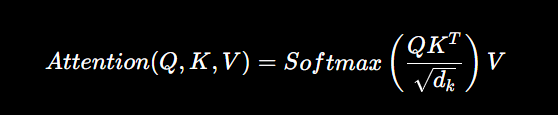

#23. Why divide by √dk?

As the vector size increases, dot-product values become very large. Large values make Softmax produce extremely peaked probabilities, which can make training unstable.

Dividing by √dk keeps the values in a reasonable range and improves learning.

#24. Why is a single attention head insufficient?

A single attention head can only focus on a limited type of relationship at a time.

Football-match analogy:

One camera cannot capture the entire match. Multiple cameras show different angles and events. Similarly, multiple attention heads learn different relationships such as grammar, meaning, and context simultaneously.

#25. How are multiple heads created and combined?

The embedding dimension is split across multiple heads.

Example:

Embedding Dimension = 32
Heads = 4
Each Head = 8 dimensions

Each head performs attention independently. Their outputs are concatenated and passed through a final linear layer to produce the final output.

#26. Purpose of Residual Connections and Layer Normalization

Residual Connections:
Add the original input back to the output, helping information flow through deep networks.

Layer Normalization:
Normalizes values to make training more stable and faster.

Together they improve training and prevent information loss.

#27. Role of FFN and Dropout

Feed Forward Network (FFN):
Processes each token independently and learns more complex patterns.

Dropout:
Randomly removes some connections during training to reduce overfitting and improve generalization

#28. Encoder vs Decoder and Why GPT Uses Only a Decoder

The encoder processes the entire input and builds contextual representations.

The decoder generates text one token at a time.

GPT is designed for text generation, so it only uses the decoder architecture with masked self-attention

#29. What is Masked (Causal) Self-Attention?

Masked self-attention prevents a token from seeing future tokens.

Example:

When predicting the next word in:

I love eating ___?

the model should not look at future words.

This ensures correct next-token prediction during training and inference.

#30. Autoregressive Text Generation in GPT
User provides a prompt.
GPT predicts the next token.
The predicted token is added to the input.
GPT predicts the next token again.
This process repeats until the response is complete or a stopping condition is reached.

#31. What is a KV Cache?

KV Cache stores previously computed Key and Value vectors during generation.

Without KV Cache, the model recomputes attention for all previous tokens every time a new token is generated.

Using KV Cache allows GPT to reuse previous computations, making text generation much faster and more efficient.